<a href="https://www.mbd.rwth-aachen.de/">
    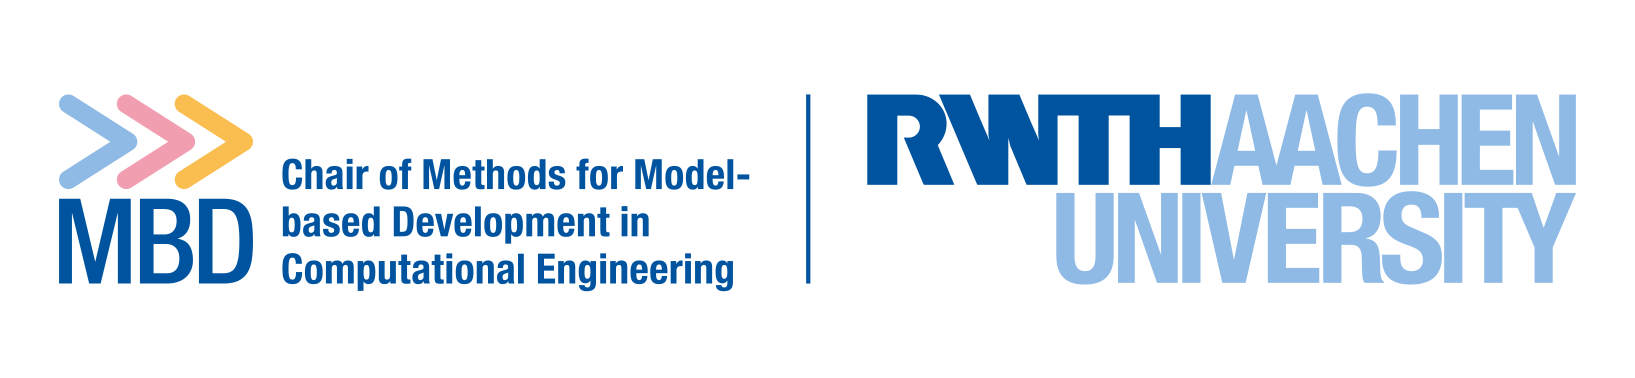
</a>
<a href="https://www.cpbl.rwth-aachen.de/">
    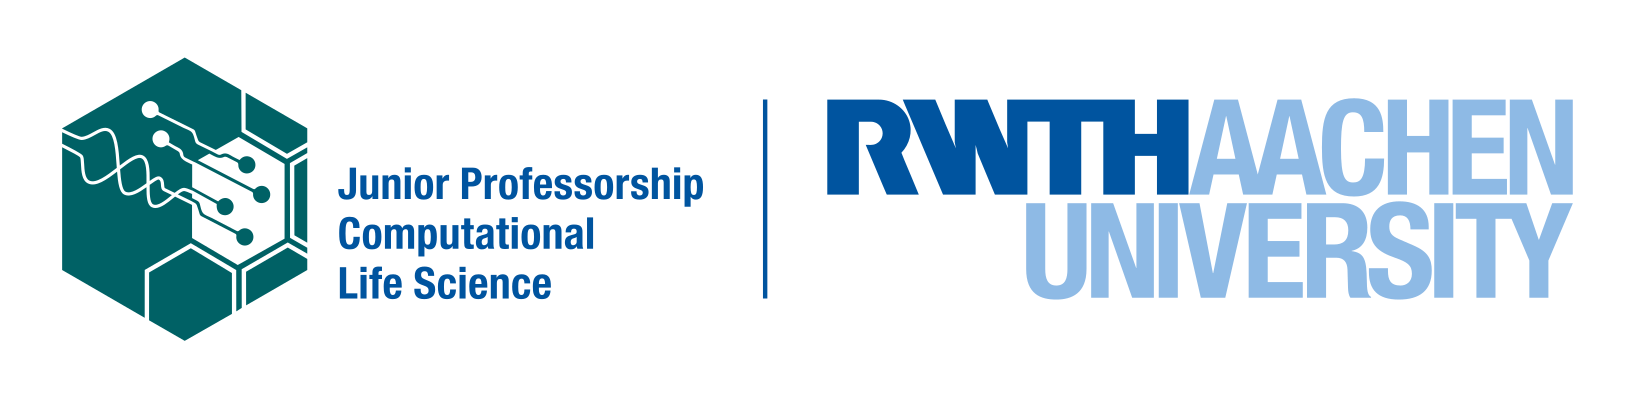
</a>

# Societal Challenges Datathon - Lecture 3

**10 December 2025**

- Dr. Marvin van Aalst (marvin.van.aalst@rwth-aachen.de)
- Nazanin Bagherinejad (bagherinejad@mbd.rwth-aachen.de)

**Credit**
  
This lecture is based on original work by Ann-Kathrin Edrich, Anna Simson and Nazanin Bagherinejad



## <span style="color: #6200EE">Note</span>

In the following I frequently import different sklearn models in their respective code cells, e.g. `from sklearn.linear_model import LinearRegression`.  
This is for educational purposes and to keep the examples concise.  
In general, please always import all required inputs at the **top** of the notebook.  
This is recommended practice and makes your code a lot easier to reason about.  

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import pandas as pd
from matplotlib.axes import Axes
from scipy import stats
from sklearn.datasets import load_digits, load_iris, make_blobs, make_classification
from sklearn.discriminant_analysis import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

Array = npt.NDArray[np.float64]


rng = np.random.default_rng(seed=42)


def plot_decision_boundary(
    model,
    features: Array,
    target: Array,
    title: str,
    ax: Axes | None = None,
    n: int = 100,
) -> None:
    if ax is None:
        _, ax = plt.subplots()

    x, y = np.meshgrid(
        np.linspace(features[:, 0].min(), features[:, 0].max(), n),
        np.linspace(features[:, 1].min(), features[:, 1].max(), n),
    )
    z = model.predict(
        np.concatenate((x.reshape(-1, 1), y.reshape(-1, 1)), axis=1)
    ).reshape(x.shape)

    ax.contourf(x, y, z, alpha=0.8)
    ax.scatter(features[:, 0], features[:, 1], c=target, edgecolors="k")
    ax.set_title(title)


class Dataset:
    def __init__(self, name: str, features: Array, target: Array) -> None:
        # store data
        self.name = name
        self.features = features
        self.target = target

        # Split features & target
        f1, f2, t1, t2 = train_test_split(features, target, train_size=0.8)

        # Store splitted features & target as well
        self.features_train = f1
        self.features_test = f2
        self.target_train = t1
        self.target_test = t2

    def train(self) -> tuple[Array, Array]:
        return self.features_train, self.target_train

    def test(self) -> tuple[Array, Array]:
        return self.features_test, self.target_test

    def plot(self, ax: Axes | None = None) -> Axes:
        if ax is None:
            _, ax = plt.subplots()

        ax.scatter(self.features[:, 0], self.features[:, 1], c=self.target)
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")
        ax.set_title(self.name)
        return ax

## Models

scikit-learn (`sklearn`) has a similar API for most of its models 

```python
# Step 1: fit model
model = Model().fit(features, targets)

# Step 2: process
## In case of e.g. preprocessors
features_trans = model.transform()

## In case of regression / classification models
targets_pred = model.predict(features)

```

## Choosing the right estimator

<img src="assets/ml_map.svg" style="max-width: 1000px; background: white" />

## Regression

### Linear regression

LinearRegression fits a linear model with coefficients w = (w1, ..., wp) to minimize the residual sum of squares between the observed targets in the dataset, and the targets predicted by the linear approximation


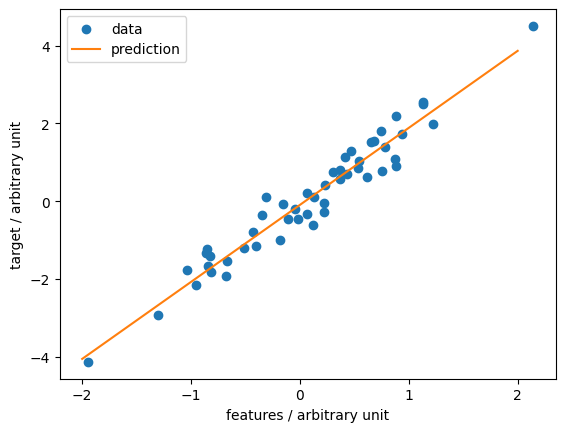

In [2]:
from sklearn.linear_model import LinearRegression

features = rng.normal(loc=0, scale=1, size=50).reshape(-1, 1)
target = 2 * features + rng.normal(loc=0, scale=0.5, size=50).reshape(-1, 1)


lin_model = LinearRegression()  # Create model
lin_model.fit(features, target)  # fit model to data

# Create features used for prediction
features_pred = np.linspace(-2, 2).reshape(-1, 1)
target_pred = lin_model.predict(features_pred)

fig, ax = plt.subplots()
ax.scatter(features, target, label="data")
ax.plot(features_pred, target_pred, color="C1", label="prediction")
ax.set_xlabel("features / arbitrary unit")
ax.set_ylabel("target / arbitrary unit")
ax.legend()
plt.show()

### Polynomial regression

Polynomial regression in scikit-learn is done by transforming the input features into polynomial form and then doing linear regression on the transformed form.

`PolynomialFeatures` generates a new feature matrix consisting of all polynomial combinations of the features with degree less than or equal to the specified degree. For example, if an input sample is two dimensional and of the form `[a, b]`, the degree-2 polynomial features are `[1, a, b, a^2, ab, b^2]`.

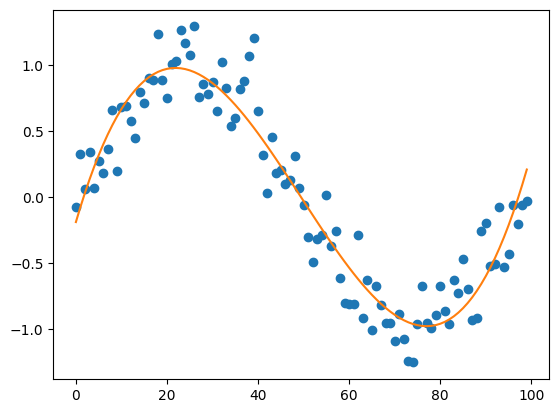

In [3]:
from sklearn.preprocessing import PolynomialFeatures

n = 100
true_data = np.sin(np.linspace(0, 2 * np.pi, n))
data = pd.Series(true_data + rng.normal(loc=0, scale=0.2, size=n))

features = data.index.to_numpy().reshape(-1, 1)
targets = data.to_numpy().reshape(-1, 1)

fig, ax = plt.subplots()
data.plot(marker="o", linestyle="none", ax=ax)

poly_features = PolynomialFeatures(degree=3, include_bias=False).fit_transform(features)
poly_model = LinearRegression(fit_intercept=True).fit(poly_features, targets)

ax.plot(features, poly_model.predict(poly_features))
plt.show()

## Classification

### Logistic regression

Logistic regression is a statistical and machine-learning method used to model the probability that an input belongs to a particular class, typically in binary classification. It applies the logistic (sigmoid) function to a linear combination of features to map predictions to values between 0 and 1. The model is trained by adjusting its weights to minimize a loss function, usually cross-entropy, so that predicted probabilities match observed outcomes.


In [4]:
def plot_distribution_and_values(ax, d, features, color: str) -> None:
    # ppf = Percent point function
    # pfd = Probability density function
    ax.plot(
        x := np.linspace(d.ppf(0.001), d.ppf(0.999), 101),
        d.pdf(x),
        color=color,
    )
    ax.scatter(
        features,
        np.full(shape=len(features), fill_value=0),
        color=color,
        alpha=0.2,
    )


# Create two distributions
d1 = stats.norm(loc=-1.0, scale=1.0)
d2 = stats.norm(loc=1.0, scale=1.0)

# Create features and target from those distributions
# rvs = Generate random variables
features = np.append(d1.rvs(size=20), d2.rvs(size=20)).reshape(-1, 1)
target = np.append(np.zeros(20), np.ones(20))
features_test = np.append(d1.rvs(size=20), d2.rvs(size=20)).reshape(-1, 1)
target_test = np.append(np.zeros(20), np.ones(20))

#### Single feature

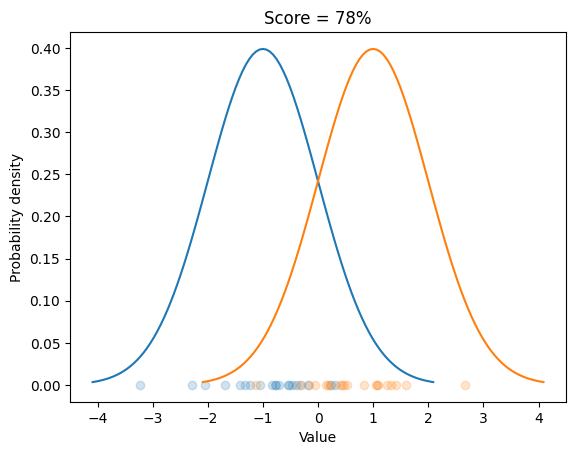

In [5]:
from sklearn.linear_model import LogisticRegression

# Train and score model
model = LogisticRegression().fit(features, target)


# Plot underlying distribution and draw data points as example features
fig, ax = plt.subplots()
plot_distribution_and_values(
    ax,
    d1,
    features[np.where(target == 0)],
    color="C0",
)
plot_distribution_and_values(
    ax,
    d2,
    features[np.where(target == 1)],
    color="C1",
)
ax.set(
    xlabel="Value",
    ylabel="Probability density",
    title=f"Score = {model.score(features_test, target_test):.0%}",
)
plt.show()

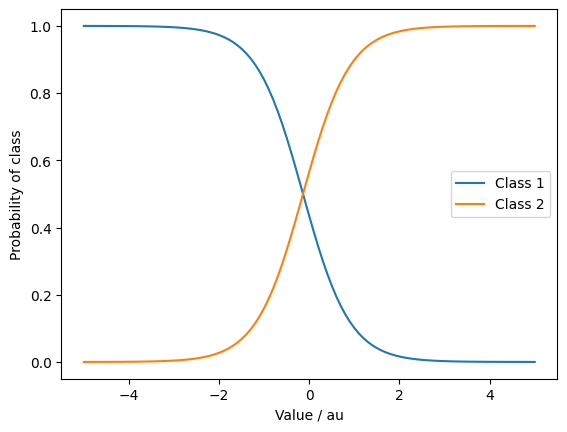

In [6]:
x = np.linspace(-5, 5, 101)
p = model.predict_proba(x.reshape(-1, 1))

fig, ax = plt.subplots()
ax.plot(x, p[:, 0], label="Class 1")
ax.plot(x, p[:, 1], label="Class 2")
ax.legend()
ax.set(xlabel="Value / au", ylabel="Probability of class")
plt.show()

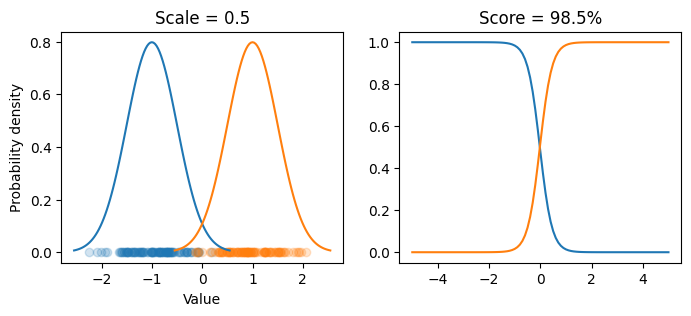

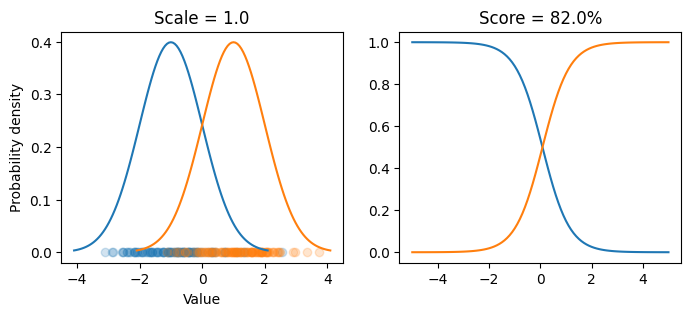

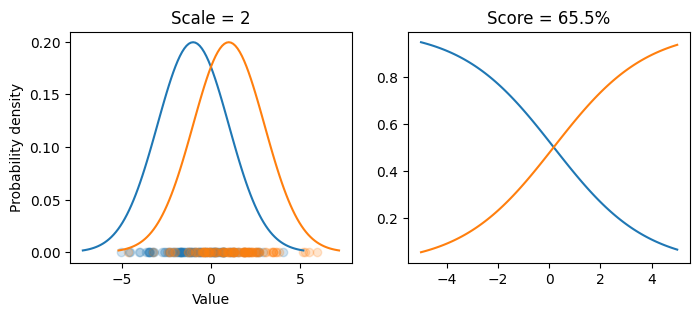

In [7]:
size = 100

for scale in [0.5, 1.0, 2]:
    d1 = stats.norm(loc=-1.0, scale=scale)
    d2 = stats.norm(loc=1.0, scale=scale)

    features = np.append(
        d1.rvs(size=size),
        d2.rvs(size=size),
    ).reshape(-1, 1)
    target = np.append(np.zeros(size), np.ones(size))

    features_test = np.append(
        d1.rvs(size=size),
        d2.rvs(size=size),
    ).reshape(-1, 1)
    target_test = np.append(np.zeros(size), np.ones(size))

    model = LogisticRegression().fit(features, target)

    x = np.linspace(-5, 5, 101)
    p = model.predict_proba(x.reshape(-1, 1))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
    ax1.set(
        title=f"Scale = {scale}",
        xlabel="Value",
        ylabel="Probability density",
    )
    plot_distribution_and_values(ax1, d1, features[np.where(target == 0)], color="C0")
    plot_distribution_and_values(ax1, d2, features[np.where(target == 1)], color="C1")

    # Plot 2
    ax2.set(title=f"Score = {model.score(features_test, target_test):.1%}")
    ax2.plot(x, p[:, 0])
    ax2.plot(x, p[:, 1])


#### Two features

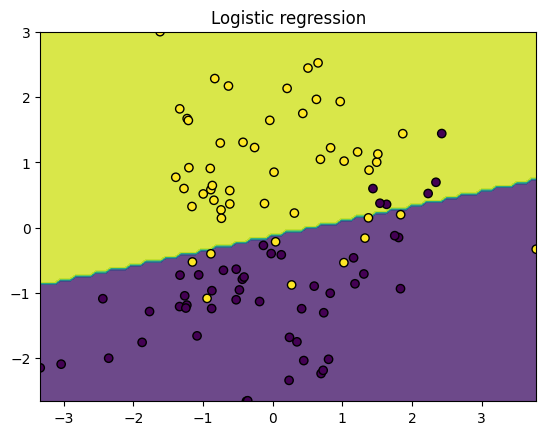

In [8]:
features, target = make_classification(n_features=2, n_redundant=0)
model = LogisticRegression().fit(features, target)
plot_decision_boundary(model, features, target, "Logistic regression")

### K-nearest neighbor

A k nearest neighbors classifier predicts the class of a new data point by looking at the classes of the k most similar points in the training set, usually based on distance. It assumes that points close to each other in feature space tend to share the same label. The predicted class is chosen by majority vote among those neighbors, which makes the method simple, intuitive, and nonparametric.


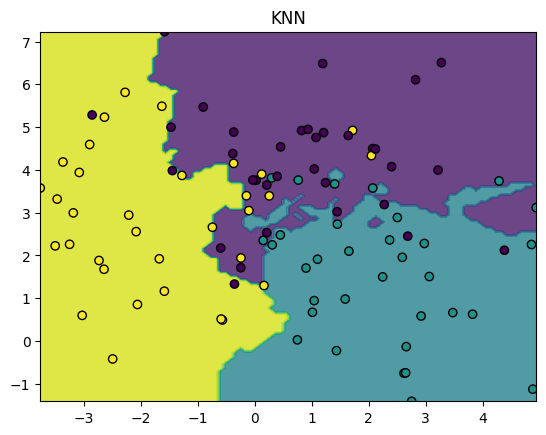

In [9]:
from sklearn.neighbors import KNeighborsClassifier

blobs = Dataset(
    "blobs",
    *make_blobs(
        n_samples=100,
        centers=3,
        cluster_std=1.5,
        random_state=0,
    ),
)

plot_decision_boundary(
    model=KNeighborsClassifier().fit(*blobs.train()),
    features=blobs.features,
    target=blobs.target,
    title="KNN",
)

### Support vector machines

A support vector machine classifier finds the decision boundary that best separates classes by maximizing the margin between them, creating the most robust separation possible. It represents this boundary using only a subset of training samples called support vectors, which define the margin. With kernel functions it can map data into higher dimensional spaces, allowing it to handle complex and non-linear classification tasks while maintaining strong generalization.


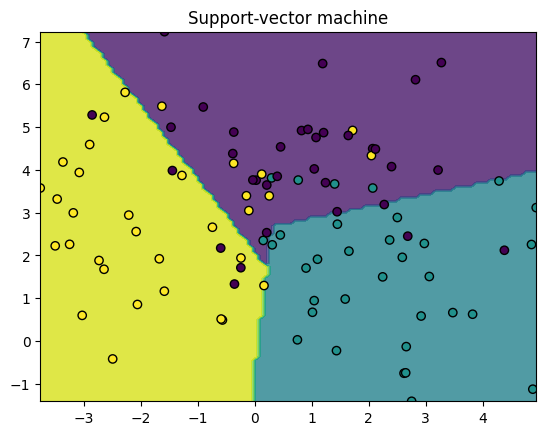

In [10]:
from sklearn.svm import SVC

plot_decision_boundary(
    model=SVC(kernel="linear").fit(*blobs.train()),
    features=blobs.features,
    target=blobs.target,
    title="Support-vector machine",
)

### Decision trees

A decision tree classifier predicts a target by recursively splitting the data into branches based on feature values, creating a flowchart like structure. Each split aims to increase the purity of the resulting groups using criteria such as information gain or Gini impurity. The final prediction comes from the class most common in the leaf node reached by following the feature based questions.


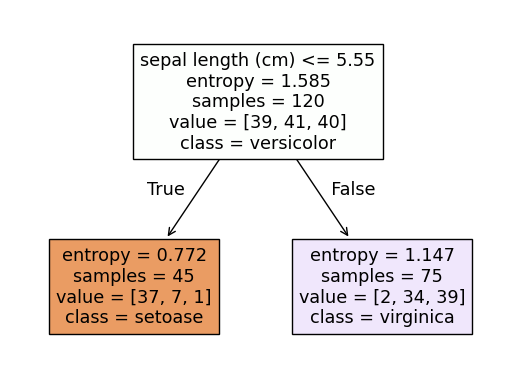

In [11]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

_temp = load_iris()
iris = Dataset("iris", _temp.data[:, :2], _temp.target)  # type: ignore


model = DecisionTreeClassifier(max_depth=1, criterion="entropy", random_state=0).fit(
    *iris.train()
)
tree.plot_tree(
    model,
    filled=True,
    feature_names=[
        "sepal length (cm)",
        "sepal width (cm)",
        "petal length (cm)",
        "petal width (cm)",
    ],
    class_names=["setoase", "versicolor", "virginica"],
)
plt.show()

### Random forest

A random forest classifier creates an ensemble of decision trees, each trained on a bootstrap sample of the data with a random subset of features considered at each split. These trees make independent predictions, which are then combined by majority vote. This randomness reduces correlation among trees, resulting in a model that is robust, accurate, and resistant to overfitting.


In [12]:
from sklearn.ensemble import RandomForestClassifier

# Load a simple dataset
X, y = load_iris(return_X_y=True)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create and train the model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 1.0


### XGB (Gradient bossted trees)

A gradient boosted tree classifier builds an ensemble of decision trees in sequence, where each new tree learns to correct the errors of the previous ones. It fits these trees to the negative gradients of a chosen loss function, allowing the model to focus on the hardest examples. The final prediction is the weighted sum of all trees, producing a powerful and flexible model that often achieves state of the art performance.


In [13]:
from sklearn.ensemble import GradientBoostingClassifier

# Load a simple dataset
X, y = load_iris(return_X_y=True)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create and train the model
clf = GradientBoostingClassifier(random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


## Neural networks

A neural network classifier maps inputs to class probabilities using layers of weighted neurons, nonlinear activation functions, and a final softmax. It learns weights via gradient-based optimization, minimizing a loss such as cross-entropy on labeled data. Proper feature **scaling**, architecture depth and width, **regularization**, and training budget are key to performance and generalization.

In [14]:
# Load data
X, y = load_iris(return_X_y=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler().fit(X_train)

# Small neural network pipeline: scale -> MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(16,),  # one small hidden layer
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42,
)

# Train
mlp.fit(scaler.transform(X_train), y_train)

# Evaluate
y_pred = mlp.predict(scaler.transform(X_test))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

Accuracy: 0.911


## Cross-validation


- LeaveOneOut (LOO)
  - Use when dataset is very **small** and you want maximal training data per evaluation.
  - Good for high-bias models where variance from small test splits matters.
  - Computationally expensive (one fit per sample) and can have high variance on noisy data.
  - Not class-aware; **avoid for imbalanced classification** unless classes are well represented.

- StratifiedKFold
  - Use for classification, especially with class imbalance; **preserves class proportions in each fold**.
  - Scales better than LOO; n_splits is tunable (commonly 5–10).
  - Provides more stable performance estimates and reduces variance versus LOO.
  - Prefer when you need reproducible, balanced folds (use shuffle=True, random_state=...).

In [15]:
from sklearn.model_selection import LeaveOneOut

# Data
X, y = load_iris(return_X_y=True)

# Estimator
clf = LogisticRegression(max_iter=1000)

# Leave-One-Out CV
loo = LeaveOneOut()
y_true, y_pred = [], []

for train_idx, test_idx in loo.split(X):
    clf.fit(X[train_idx], y[train_idx])
    y_pred.append(clf.predict(X[test_idx])[0])
    y_true.append(y[test_idx][0])

print(f"LOO accuracy: {accuracy_score(y_true, y_pred):.3f}")
print(f"Evaluations performed: {len(y_true)}")

LOO accuracy: 0.967
Evaluations performed: 150


In [16]:
from sklearn.model_selection import StratifiedKFold

# Data
X, y = load_iris(return_X_y=True)

# Estimator
clf = LogisticRegression(max_iter=1000)

# Stratified 5-fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    # Show class distribution per fold
    y_train, y_test = y[train_idx], y[test_idx]
    print(
        f"Fold {fold} train class counts:",
        {c: int((y_train == c).sum()) for c in np.unique(y)},
    )
    print(
        f"Fold {fold} test  class counts:",
        {c: int((y_test == c).sum()) for c in np.unique(y)},
    )

    # Fit and evaluate
    clf.fit(X[train_idx], y_train)
    y_pred = clf.predict(X[test_idx])
    accs.append(accuracy_score(y_test, y_pred))

print(f"Mean accuracy over folds: {np.mean(accs):.3f} ± {np.std(accs):.3f}")

Fold 1 train class counts: {np.int64(0): 40, np.int64(1): 40, np.int64(2): 40}
Fold 1 test  class counts: {np.int64(0): 10, np.int64(1): 10, np.int64(2): 10}
Fold 2 train class counts: {np.int64(0): 40, np.int64(1): 40, np.int64(2): 40}
Fold 2 test  class counts: {np.int64(0): 10, np.int64(1): 10, np.int64(2): 10}
Fold 3 train class counts: {np.int64(0): 40, np.int64(1): 40, np.int64(2): 40}
Fold 3 test  class counts: {np.int64(0): 10, np.int64(1): 10, np.int64(2): 10}
Fold 4 train class counts: {np.int64(0): 40, np.int64(1): 40, np.int64(2): 40}
Fold 4 test  class counts: {np.int64(0): 10, np.int64(1): 10, np.int64(2): 10}
Fold 5 train class counts: {np.int64(0): 40, np.int64(1): 40, np.int64(2): 40}
Fold 5 test  class counts: {np.int64(0): 10, np.int64(1): 10, np.int64(2): 10}
Mean accuracy over folds: 0.967 ± 0.030


## Hyperparameter optimisation

In [17]:
from sklearn.model_selection import GridSearchCV

gs = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {
        "max_depth": [2, 5, 10, None],
        "min_samples_split": [2, 5, 10],
        "criterion": ["entropy"],
    },
    cv=5,
)
gs.fit(*iris.train())

# Print the best hyperparameters
print("Best Hyperparameters:", gs.best_params_)

print(f"Train Accuracy with Best Model: {gs.best_estimator_.score(*iris.train()):.2f}")
print(f"Test Accuracy with Best Model: {gs.best_estimator_.score(*iris.test()):.2f}")

Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}
Train Accuracy with Best Model: 0.85
Test Accuracy with Best Model: 0.67


## Dimensionality reduction

### Principle component analysis

Linear dimensionality reduction using Singular Value Decomposition of the data to project it to a lower dimensional space. The input data is centered but not scaled for each feature before applying the SVD.



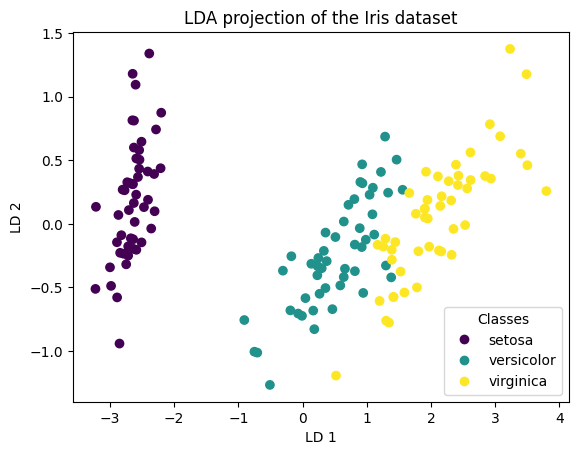

In [18]:
from sklearn.decomposition import PCA

# Load data
iris = load_iris()
X, y, target_names = iris["data"], iris["target"], iris["target_names"]

# Fit PCA and reduce to two components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a figure and axes
fig, ax = plt.subplots()
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
ax.set_xlabel("LD 1")
ax.set_ylabel("LD 2")
ax.set_title("LDA projection of the Iris dataset")
ax.legend(scatter.legend_elements()[0], target_names, title="Classes")
plt.show()

### Linear Discriminant Analysis.

A classifier with a linear decision boundary, generated by fitting class conditional densities to the data and using Bayes' rule.

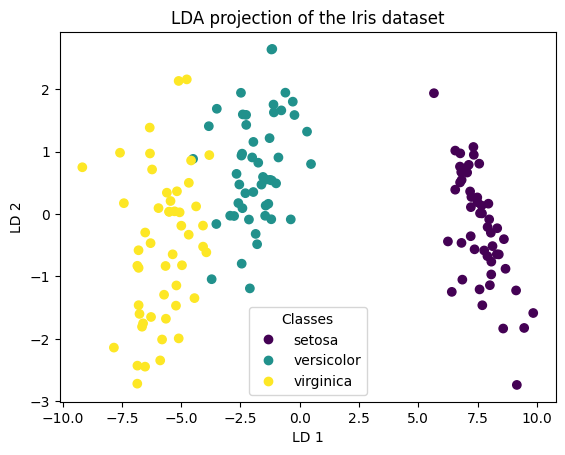

In [19]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Load data
iris = load_iris()
X, y, target_names = iris["data"], iris["target"], iris["target_names"]

# Fit LDA and project to two dimensions
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

# Create a figure and axes
fig, ax = plt.subplots()
scatter = ax.scatter(X_lda[:, 0], X_lda[:, 1], c=y)
ax.set_xlabel("LD 1")
ax.set_ylabel("LD 2")
ax.set_title("LDA projection of the Iris dataset")
ax.legend(scatter.legend_elements()[0], target_names, title="Classes")
plt.show()

### T-distributed Stochastic Neighbor Embedding.

t-SNE is a tool to visualize high-dimensional data. It converts similarities between data points to joint probabilities and tries to minimize the Kullback-Leibler divergence between the joint probabilities of the low-dimensional embedding and the high-dimensional data. t-SNE has a cost function that is not convex, i.e. with different initializations we can get different results.

Key ideas:
- Works best for visualization (not a general embedding for downstream models).
- Sensitive to `perplexity` (roughly, number of nearest neighbors) and random seed.
- Use standardized inputs and try a few parameter settings.


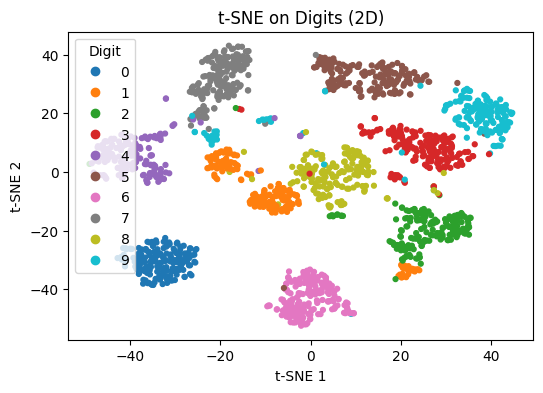

In [20]:
from sklearn.manifold import TSNE

# Load a high-dimensional dataset
digits = load_digits()
X, y = digits.data, digits.target

# Optional: standardize features (often helps t-SNE)
X_std = StandardScaler().fit_transform(X)

# t-SNE to 2D
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42,
)
X_emb = tsne.fit_transform(X_std)

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
scatter = ax.scatter(X_emb[:, 0], X_emb[:, 1], c=y, s=12, cmap="tab10")
ax.set(
    title="t-SNE on Digits (2D)",
    xlabel="t-SNE 1",
    ylabel="t-SNE 2",
)
ax.legend(*scatter.legend_elements(), title="Digit")
plt.show()

## Pipelines

You can create readable pipelines and avoid common mistakes (e.g. standard scaling training features, but not test features) using the `Pipeline`s abstraction provided by`sklearn`.

In [21]:
from sklearn.pipeline import Pipeline

# Load data
X, y = load_iris(return_X_y=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Small neural network pipeline: scale -> MLP
clf = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=(16,),  # one small hidden layer
                activation="relu",
                solver="adam",
                max_iter=500,
                random_state=42,
            ),
        ),
    ]
)

# Train
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

Accuracy: 0.911


c:\Users\Yajesh\Workspace\Societal-challenges-datathon\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


## Analysing / comparing models

### Confusion matrix

A confusion matrix is a table that compares a model’s predicted labels to the true labels, with rows as actual classes and columns as predicted classes. 
It counts correct **predictions and error types** (e.g., true positives, false negatives) for each class. From it, one can derive metrics like accuracy, precision, recall, and F1, and spot class imbalance or systematic misclassifications.

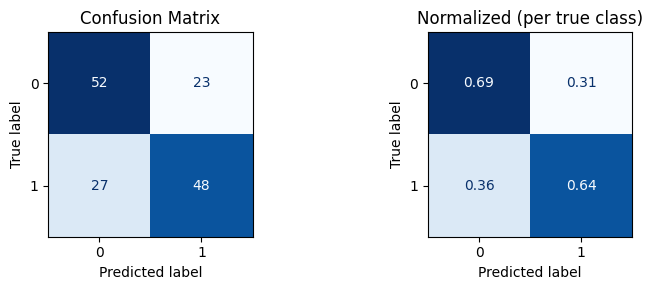

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

# Toy binary data
X, y = make_classification(
    n_samples=500, n_features=10, n_informative=4, n_redundant=2, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Train a simple model
clf = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)

# Plot raw and normalized confusion matrices
fig, ax = plt.subplots(1, 2, figsize=(8, 3))

ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test, ax=ax[0], cmap="Blues", colorbar=False
)
ax[0].set_title("Confusion Matrix")

ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test, normalize="true", ax=ax[1], cmap="Blues", colorbar=False
)
ax[1].set_title("Normalized (per true class)")

plt.tight_layout()
plt.show()

### ROC curve

An ROC (Receiver Operating Characteristic) curve plots the true positive rate (sensitivity) against the false positive rate (1 − specificity) across all classification thresholds. It visualizes the trade-off between correctly detecting positives and raising false alarms, independent of any single threshold. The area under the curve (AUC) summarizes overall performance, where 0.5 indicates chance-level and 1.0 indicates perfect discrimination.

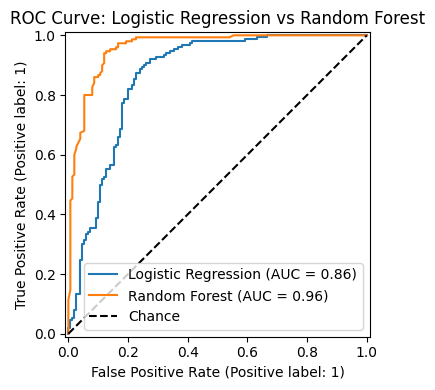

In [23]:
from sklearn.metrics import RocCurveDisplay

# Synthetic binary classification data
X, y = make_classification(
    n_samples=1000, n_features=20, n_informative=5, n_redundant=2, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Two models
lr = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_train, y_train)

# Plot ROC for both
fig, ax = plt.subplots(figsize=(6, 4))
RocCurveDisplay.from_estimator(lr, X_test, y_test, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_estimator(rf, X_test, y_test, name="Random Forest", ax=ax)

# Chance line
ax.plot([0, 1], [0, 1], "k--", label="Chance")
ax.set_title("ROC Curve: Logistic Regression vs Random Forest")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Building diverse baselines

- Spin up a couple of different models without hyperparameter optimisation to get a good baseline
  - mean prediction
  - linear models
  - logistic regression
  - random forest / XGBoost
  - small neural network (MLP)

## Next lecture

- **Explainable machine learning** (XAI)
  - shaply values and LIME
- Boosting prediction accuracy
- Single model "ensemble" approaches: using multiple random seeds
- Multiple model ensemble approaches: Hill climbing & stacking
